# Model Development and Evaluation
## Wisconsin Diagnostic Breast Cancer 

---

## Motivating Problem
#### Can we develop a machine learning model to assist radiologists in distinguishing malignant from benign breast masses using cell morphology features, in order to reduce unnecessary biopsies while maintaining high cancer detection rates?

## Notebook Structure
This notebook trains and evaluates several machine learning models to classify breast tumors as benign or malignant using the [Wisconsin Diagnostic Breast Cancer dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), which contains features describing 10 core characteristics of cell nuclei present in the digitized images of fine needle aspirates.  

**Models Evaluated**:
- Logistic Regression (No regularization)
- Logistic Regression (L1 regularization)
- Logistic Regression (L2 regularization)
- Random Forest
- Support Vector Machine

**Evaluation Metrics**: accuracy, sensitivity, specificity, AUC-ROC, and confusion matrices.

<!-- ### Notebook structure
- Data preparation (load data, split)
- Baseline Model: Logistic Regression (train + evaluate)
- Logistic Regression (L1 Regularization) (train + evaluate)
- Random Forest (train + evaluate)
- SVM
- Model comparison (compare_models)
- Hyperparameter tuning (NEW)
- Evaluate tuned models
- Confusion Matrices
- ROC curve comparison
- Feature Importance (RF) (interpretability) (medically relevant predictors)
- Logistic Regression Coefficient Plot (which features increase malignant risk)
    - positive coefficient = higher malignancy risk
    - negative coefficient = benign tendency
- Discussion 
- Key Findings  -->

## Imports
_The src/ folder contains python (.py) scripts needed for running the .ipynb files contained in the notebooks/ (this) folder. The functions in each script help with a certain aspect of the project. At the top of each .ipynb in the notebooks/ folder you will find a code block that sets up access to the src/ folder and its functions. If you remove this code block you will not be able to properly run the notebook._

In [1]:
import sys
from pathlib import Path

# Get repo root (one level above notebooks/)
repo_root = Path().resolve().parent
src_path = repo_root / "src"

# Add src folder to Python path
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# import custom modules (located in src/)
import visualization as vis 
from preprocessing import load_raw_data, get_Xy, split_data
from pipelines import logistic_pipeline, rf_pipeline, svm_pipeline
# from tune import get_param_grid, tune_model, extract_feature_importance
from evaluate import tune_and_evaluate, cross_validate_model
from compare import compare_models, stack_tuned_metrics

# Suppress sklearn warnings (clean output)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# settings
sns.set_style(style="white")
print("> Loaded required libraries")

> Loaded required libraries


In [2]:
# hard-coded variables or flags
cols = {"malignant": "darkblue", "benign": "#04b2d1"} # target
# cols = {"malignant": "#1f77b4", "benign": "#ff7f0e"} # target
measures = ["mean", "error", "worst"]
measures_cols = {"mean": "#3498DB", "error": "#F39C12", "worst": "#E74C3C"} # measures

## Data & Model Preparation
The raw dataset is loaded and cleaned using a helper function. Cleaning steps include standardizing column names and encoding the target variable (malignant = 1, benign = 0). The data are separated into features (X) and target (y) before being split into training and test sets. 

As discussed in the [exploratory data analysis (01_eda.ipynb)](https://github.com/sarahcreighton/breast-cancer-classifier/blob/main/notebooks/01_eda.ipynb), the dataset contains more benign tumors (63%) than malignant tumors (37%). Although the class imbalance is moderate and unlikely to severely bias model training, we stratified sampling to preserve class balance. All analyses used a 80/20 train-test split and stratified sampling.

Our analyses make use of scikit-learn pipelines to ensure proper scaling (standardization) for the logistic regression and SVM models, and to eliminate the risk of data leakage. Scaling is particularly important for this dataset due to the high degree of multicollinearity.  

In [3]:
data_path = "../data/raw/wdbc.data"
df = load_raw_data(data_path)
X, y = get_Xy(df) 
X_train, X_test, y_train, y_test = split_data(X, y)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 455
Test samples: 114


### PCA Visualization of Tumor Types
We used Principle Components Analysis (PCA) to reduce the high-dimensional feature space of our dataset to $n$ lower-dimensions to visualize how benign and malignant tumors separate. Projection onto the first two principle components reveals a strong separation between malignant and benign samples, indicating that the underlying feature space contains structure suitible for classification. The first two principle components explain roughly 63% of the variance.

<div><center><img src="../results/figures/02_pca.png" width="400"/> </center></div>

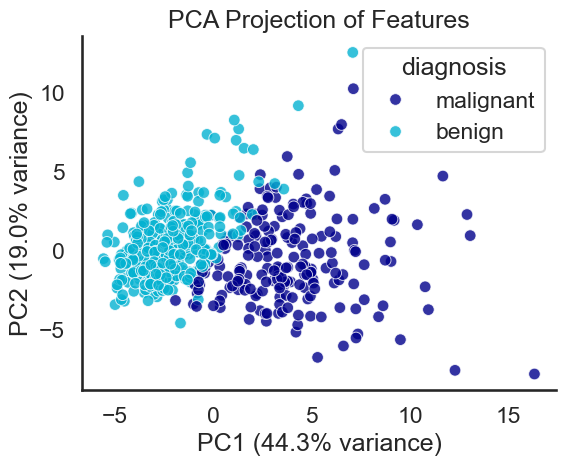

In [4]:
vis.plot_pca(df, palette=cols)

## Baseline Model Comparisons
We tested 3 different baseline classifier models: logistic regression, random forest, and support vector, using scikit-learn's default settings to identify which algorithm family works best for our dataset. 

In [5]:
base_models = {
    "Logistic (L2, Baseline)": logistic_pipeline(),
    "Random Forest (Baseline)": rf_pipeline(),
    "Support Vector (Baseline)": svm_pipeline()
}

base_res, base_cms, base_trained_models = compare_models(
    base_models, X_train, y_train, X_test, y_test
)

# Sort and highlight the max ROC-AUC
base_results = base_res.sort_values(by="Specificity", ascending=False)
base_results.style.highlight_max(color="seagreen")

,Accuracy,Sensitivity,Specificity,ROC-AUC,Precision,F1-Score
Model,,,,,,
Random Forest (Baseline),0.973700,0.928600,1.000000,0.992900,1.000000,0.963000
Support Vector (Baseline),0.973700,0.928600,1.000000,0.994700,1.000000,0.963000
"Logistic (L2, Baseline)",0.964900,0.928600,0.986100,0.996000,0.975000,0.951200


### Observations:
- performance across all classifiers and evaluation metrics were consistently high
- tuning likely will provide minimal performance increases
- sensitivity for all three baseline models was identical
- with the exception of ROC-AUC random forest and support vector had equivalent performance across the other metrics
- Logistic (L2) had the highest ROC-AUC, followed by Support Vector, then random forest
- sensitivity (recall) is often most important in medical situations (explain why)
- since all three scored identically on sensitivity, our second measure of interest is specificity - making sure people do not get unncessary procedures
- in that case, we would select SVM as our top model
- we will also perform tuning for the logistic L2, since linear models provide greater interpretability, which is important to clinicians

> Based on these results we chose both Logistic Regression and SVM to explore further

## Model Tuning
Next, we found the best hyperparameters for our chosen models and re-evaluated each one on the test data.

In [6]:
# tune and evaluate logistic regression model
lr_metrics, lr_cm, best_lr, best_lr_params, best_lr_score = tune_and_evaluate(
    "Logistic", logistic_pipeline, X_train, y_train, X_test, y_test
)

# tune and evaluate SVM model
svm_metrics, svm_cm, best_svm, best_svm_params, best_svm_score = tune_and_evaluate(
    "SVM", svm_pipeline, X_train, y_train, X_test, y_test
)

# tune and evaluate RF model (for feature importance)
rf_metrics, rf_cm, best_rf, best_rf_params, best_rf_score = tune_and_evaluate(
    "RF", rf_pipeline, X_train, y_train, X_test, y_test
)

In [ ]:
# return table of results
tuned_results = stack_tuned_metrics(
    [lr_metrics, svm_metrics],
    ["Logistic (L2, Tuned)", "SVM (Tuned)"]
)
# sort by desired metric
tuned_results.sort_values("Sensitivity", ascending=False).style.highlight_max(color="seagreen")

# # combine with corresponding baseline
# all_results = pd.concat([base_results, tuned_results])
# all_results = all_results.sort_values(by="Sensitivity", ascending=False)
# all_results.style.highlight_max(color="seagreen")

,Accuracy,Sensitivity,Specificity,ROC-AUC,Precision,F1-Score
"Logistic (L2, Tuned)",0.973700,0.952400,0.986100,0.986400,0.975600,0.963900
SVM (Tuned),0.973700,0.928600,1.000000,0.992700,1.000000,0.963000


#### Cross Validation
To assess model stability, we performed 5 fold cross validation on the selected tuned models.

In [8]:
scoring = "recall"
selected_models = {
    "Logistic (L2, Tuned)": best_lr,
    "SVM (Tuned)": best_svm
}

for name, model in selected_models.items():
    cv_metrics = cross_validate_model(model, X_train, y_train, cv=5, scoring="recall")

    print(f"{name}")
    print(f"Mean recall: {cv_metrics['cv_mean']:.3f} ± {cv_metrics['cv_std']:.3f}")
    print(f"Fold scores: {cv_metrics['cv_scores']}\n")

Logistic (L2, Tuned)
Mean recall: 0.947 ± 0.039
Fold scores: [0.94117647 1.         0.88235294 0.97058824 0.94117647]

SVM (Tuned)
Mean recall: 0.959 ± 0.030
Fold scores: [0.94117647 1.         0.91176471 0.97058824 0.97058824]



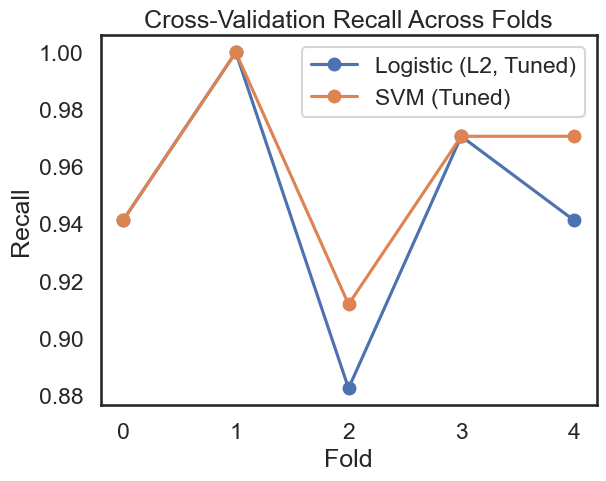

In [9]:
import matplotlib.pyplot as plt

for name, model in selected_models.items():
    cv = cross_validate_model(model, X_train, y_train, scoring="recall",cv=5)

    plt.plot(cv["cv_scores"], marker="o", label=name)

plt.ylabel("Recall")
plt.xlabel("Fold")
plt.title("Cross-Validation Recall Across Folds")
plt.legend()
plt.show()

#### Observations:
The tuned logistic model outperforms the other 4 on our measure of interest, sensitivity

**Comparing Metrics**:
- accuracy: balanced classification
- ROC-AUC/F1: imbalanced classification
- fraud/medical: recall (sensitivity)
- marketing: precision 

### Visualize Confusion Matrices

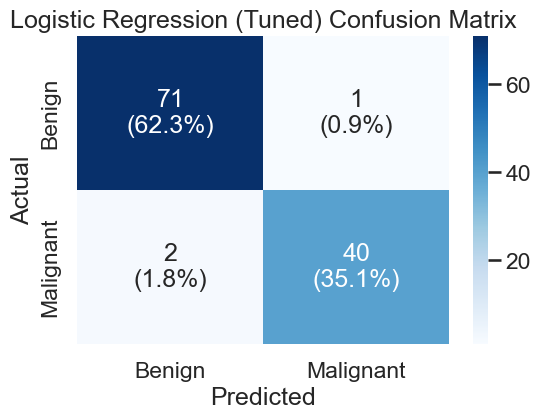

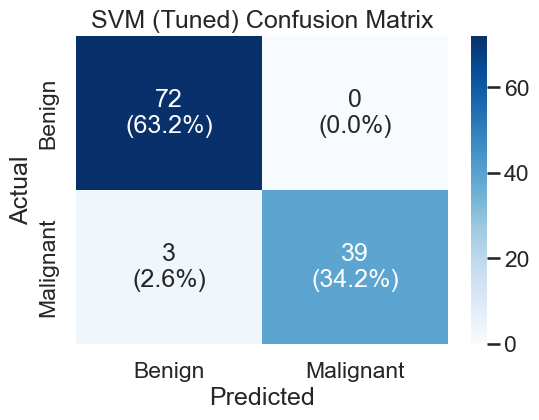

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cms = {
    "Logistic Regression (Tuned)": lr_cm,
    "SVM (Tuned)": svm_cm
}

for name, cm in cms.items():

    cm_sum = cm.sum()
    cm_pct = cm / cm_sum

    labels = np.array([
        [
            f"{cm[i,j]}\n({cm_pct[i,j]:.1%})"
            for j in range(cm.shape[1])
        ]
        for i in range(cm.shape[0])
    ])

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="Blues",
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"]
    )

    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.title(f"{name} Confusion Matrix")

    plt.show()

### Examine ROC Curves
For selected models only.

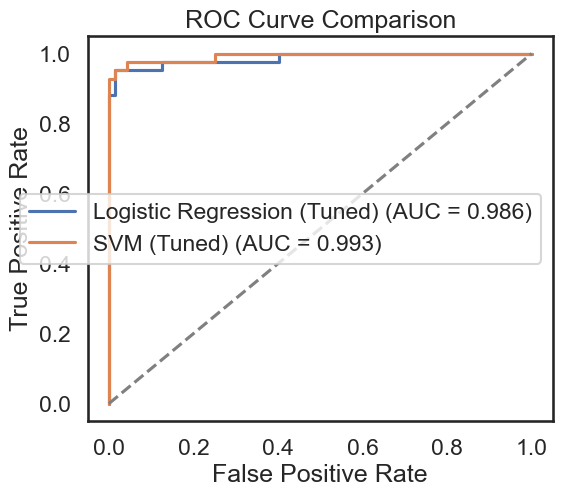

In [11]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(6,5))

models = {
    "Logistic Regression (Tuned)": best_lr,
    "SVM (Tuned)": best_svm
}

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]

    elif hasattr(model, "decision_function"):
        # fallback for SVM without probability=True
        y_proba = model.decision_function(X_test)

    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### Examine Precision-Recall Curves
For selected models only.

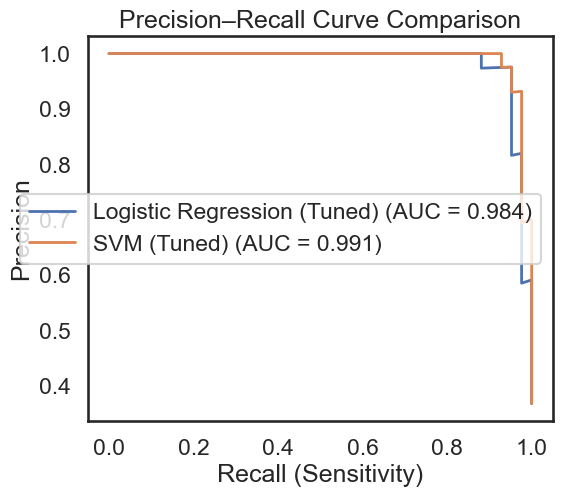

In [12]:
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(6,5))

models = {
    "Logistic Regression (Tuned)": best_lr,
    "SVM (Tuned)": best_svm
}

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]

    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)

    else:
        continue

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = auc(recall, precision)

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{name} (AUC = {pr_auc:.3f})"
    )

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()

plt.show()

---

## Feature Importance

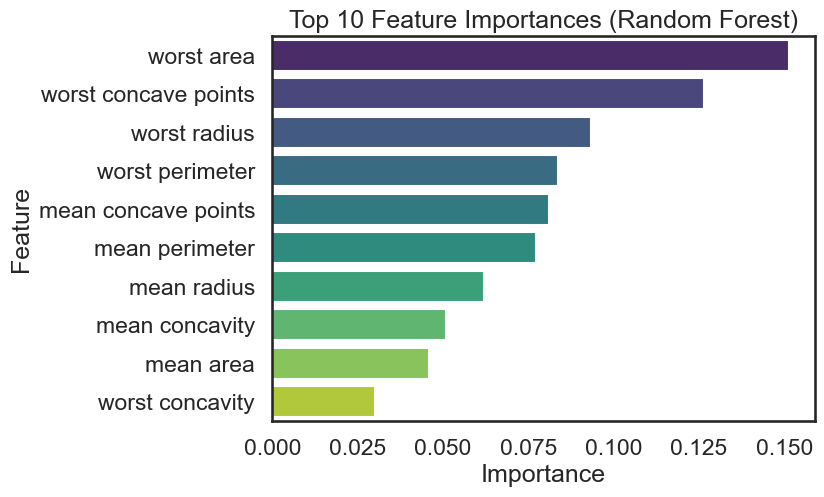

In [13]:
# # tune and evaluate logistic regression model
# rf_metrics, rf_cm, best_rf, best_rf_params, best_rf_score = tune_and_evaluate(
#     "Random Forest", rf_pipeline, X_train, y_train, X_test, y_test
# )

# Make sure Random Forest is in trained_models
if "Random Forest (Baseline)" in base_trained_models:

    rf_model = base_trained_models["Random Forest (Baseline)"]

    # Extract feature importances from the model inside the pipeline
    importances = rf_model.named_steps["model"].feature_importances_
    features = X_train.columns

    importance_df = (
        pd.DataFrame({
            "feature": features,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .head(10)
    )

    plt.figure(figsize=(7,5))

    sns.barplot(
        data = importance_df,
        x = "importance",
        y = "feature",
        hue = "feature",
        palette = "viridis"
    )

    plt.title("Top 10 Feature Importances (Random Forest)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.show()

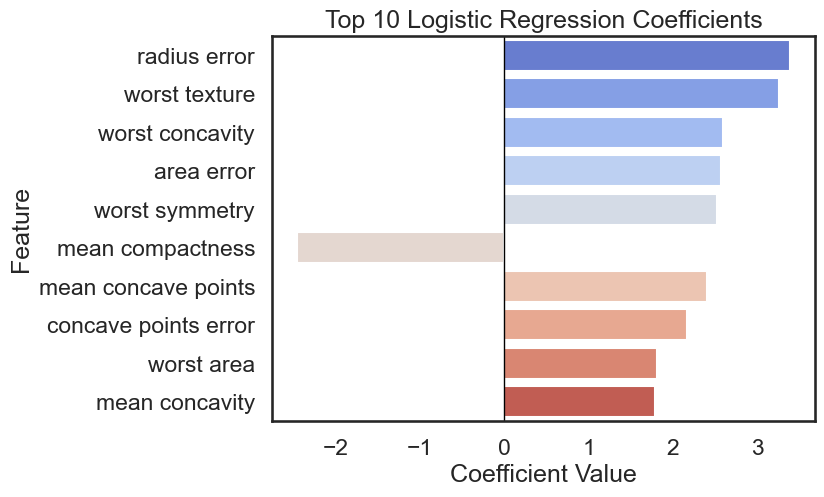

In [15]:
# Use your tuned logistic regression model
log_model = best_lr

# Extract coefficients
coefs = log_model.named_steps["model"].coef_[0]

# Create DataFrame of top 10 coefficients by absolute value
coef_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": coefs
    })
    .assign(abs_coef=lambda df: df["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .head(10)
)

plt.figure(figsize=(7,5))

sns.barplot(
    data=coef_df,
    x="coefficient",
    y="feature",
    hue = "feature",
    palette="coolwarm"
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

### Threshold Comparisons
Define what they are, why we care.


=== Threshold Analysis for Logistic Regression (Tuned) ===

--- Threshold = 0.5 ---
Accuracy: 0.9737
Sensitivity: 0.9524
Specificity: 0.9861
AUC-ROC: 0.9864


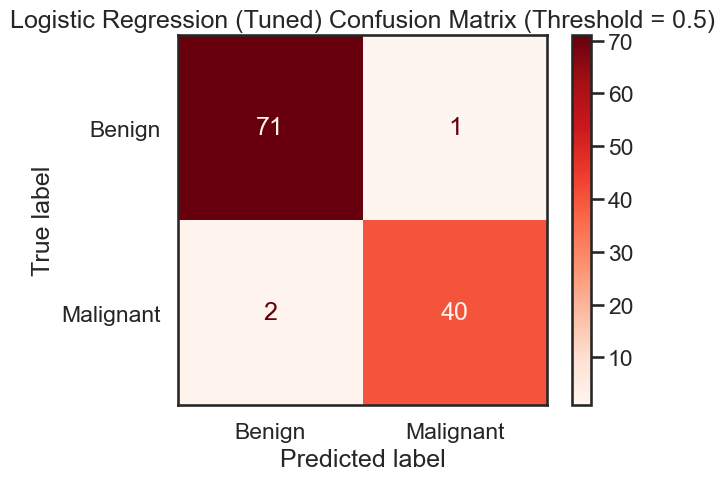


--- Threshold = 0.4 ---
Accuracy: 0.9737
Sensitivity: 0.9524
Specificity: 0.9861
AUC-ROC: 0.9864


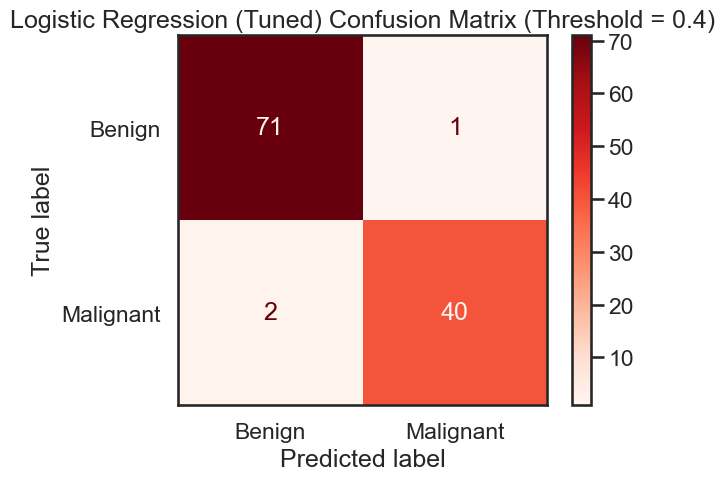


--- Threshold = 0.3 ---
Accuracy: 0.9737
Sensitivity: 0.9524
Specificity: 0.9861
AUC-ROC: 0.9864


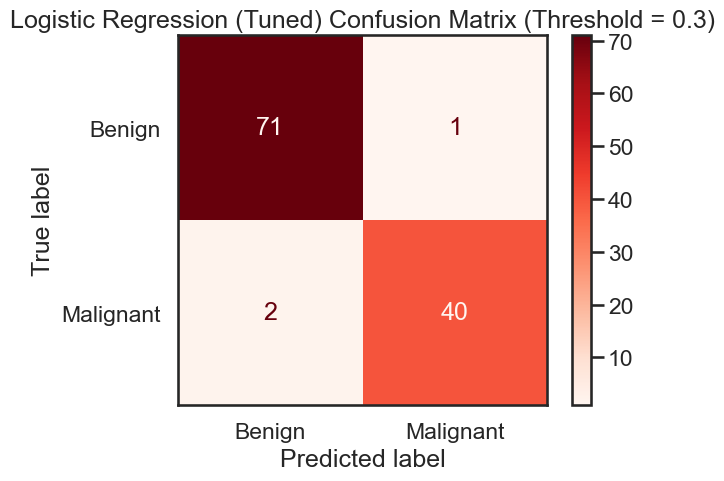


--- Threshold = 0.2 ---
Accuracy: 0.9737
Sensitivity: 0.9524
Specificity: 0.9861
AUC-ROC: 0.9864


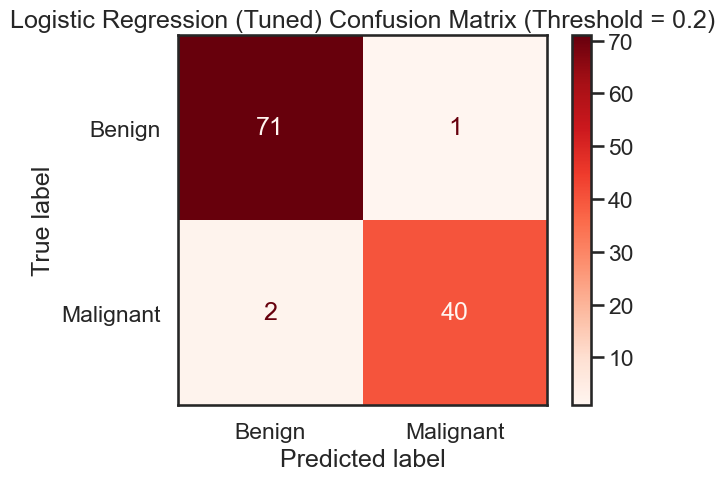


--- Threshold Comparison Table for Logistic Regression (Tuned) ---
   Threshold  Accuracy  Sensitivity  Specificity   AUC-ROC
0        0.5  0.973684     0.952381     0.986111  0.986442
1        0.4  0.973684     0.952381     0.986111  0.986442
2        0.3  0.973684     0.952381     0.986111  0.986442
3        0.2  0.973684     0.952381     0.986111  0.986442

=== Threshold Analysis for SVM (Tuned) ===

--- Threshold = 0.5 ---
Accuracy: 0.9737
Sensitivity: 0.9286
Specificity: 1.0000
AUC-ROC: 0.9927


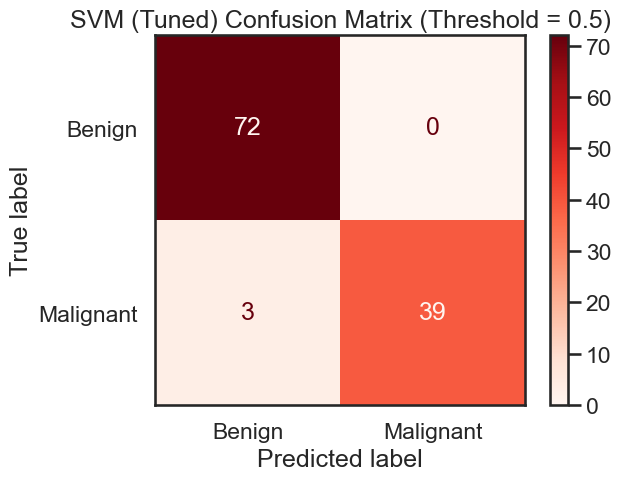


--- Threshold = 0.4 ---
Accuracy: 0.9737
Sensitivity: 0.9524
Specificity: 0.9861
AUC-ROC: 0.9927


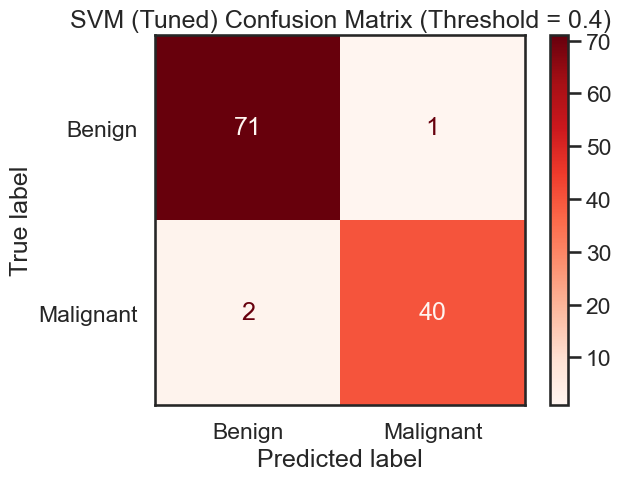


--- Threshold = 0.3 ---
Accuracy: 0.9649
Sensitivity: 0.9524
Specificity: 0.9722
AUC-ROC: 0.9927


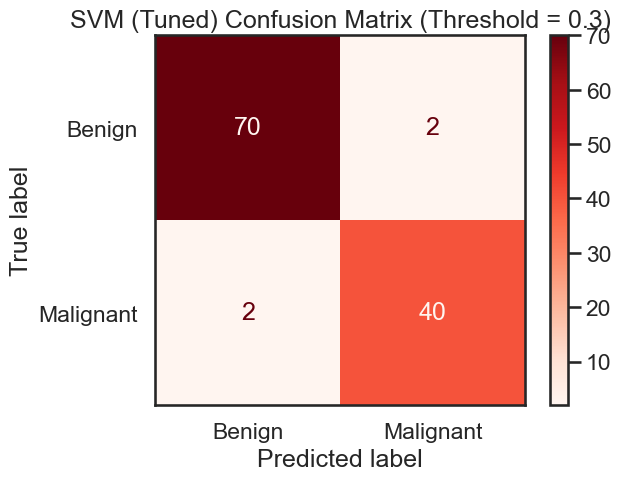


--- Threshold = 0.2 ---
Accuracy: 0.9474
Sensitivity: 0.9762
Specificity: 0.9306
AUC-ROC: 0.9927


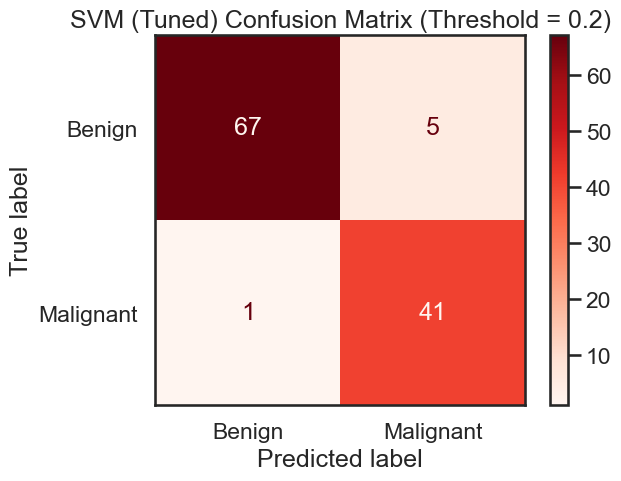


--- Threshold Comparison Table for SVM (Tuned) ---
   Threshold  Accuracy  Sensitivity  Specificity   AUC-ROC
0        0.5  0.973684     0.928571     1.000000  0.992725
1        0.4  0.973684     0.952381     0.986111  0.992725
2        0.3  0.964912     0.952381     0.972222  0.992725
3        0.2  0.947368     0.976190     0.930556  0.992725


In [16]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    recall_score,
    roc_auc_score
)

# Models to analyze
selected_models = {
    "Logistic Regression (Tuned)": best_lr,
    "SVM (Tuned)": best_svm
}

# Thresholds to test
thresholds = [0.5, 0.4, 0.3, 0.2]

for name, model in selected_models.items():

    print(f"\n=== Threshold Analysis for {name} ===")

    # Get probabilities
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        print(f"{name} does not support probability or decision_function")
        continue

    results = []

    for t in thresholds:
        y_pred_thresh = (y_proba >= t).astype(int)

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred_thresh)
        tn, fp, fn, tp = cm.ravel()

        # Metrics
        accuracy = accuracy_score(y_test, y_pred_thresh)
        sensitivity = recall_score(y_test, y_pred_thresh)  # same as recall
        specificity = tn / (tn + fp)
        auc_roc = roc_auc_score(y_test, y_proba)

        results.append([t, accuracy, sensitivity, specificity, auc_roc])

        # Print metrics
        print(f"\n--- Threshold = {t} ---")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Sensitivity: {sensitivity:.4f}")
        print(f"Specificity: {specificity:.4f}")
        print(f"AUC-ROC: {auc_roc:.4f}")

        # Confusion matrix plot
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
        disp.plot(cmap="Reds")
        plt.title(f"{name} Confusion Matrix (Threshold = {t})")
        plt.show()

    # Create summary table for this model
    threshold_results = pd.DataFrame(
        results,
        columns=["Threshold", "Accuracy", "Sensitivity", "Specificity", "AUC-ROC"]
    )

    print(f"\n--- Threshold Comparison Table for {name} ---")
    print(threshold_results)

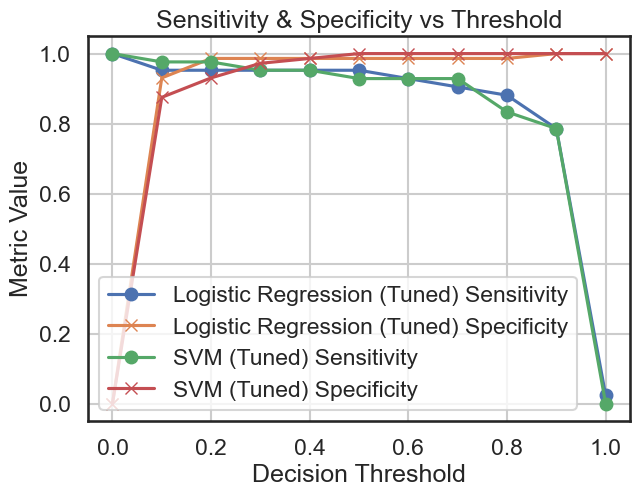

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, confusion_matrix

# Models to plot
models = {
    "Logistic Regression (Tuned)": best_lr,
    "SVM (Tuned)": best_svm
}

thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

plt.figure(figsize=(7,5))

for name, model in models.items():
    
    # Get predicted probabilities
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        continue

    sens_list = []
    spec_list = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        
        sens_list.append(sensitivity)
        spec_list.append(specificity)
    
    # Plot both metrics
    plt.plot(thresholds, sens_list, marker='o', label=f"{name} Sensitivity")
    plt.plot(thresholds, spec_list, marker='x', label=f"{name} Specificity")

plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("Sensitivity & Specificity vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

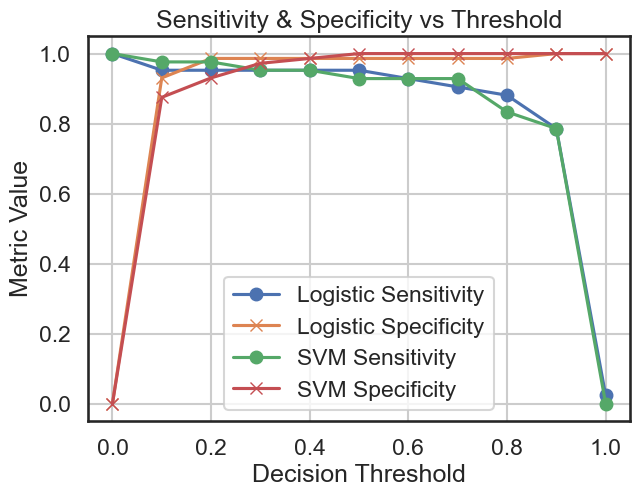

In [18]:
plt.figure(figsize=(7,5))

thresholds = np.linspace(0, 1, 11)

for name, model in {"Logistic": best_lr, "SVM": best_svm}.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
    else:
        continue

    sens_list, spec_list = [], []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        sens_list.append(tp / (tp + fn))
        spec_list.append(tn / (tn + fp))

    plt.plot(thresholds, sens_list, marker='o', label=f"{name} Sensitivity")
    plt.plot(thresholds, spec_list, marker='x', label=f"{name} Specificity")

plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("Sensitivity & Specificity vs Threshold")
plt.grid(True)
plt.legend()
plt.show()

---
---
---

## Logistic Regression Models
Logistic regression models with both L1 and L2 regularization were evaluated. L1 regularization was implemented using the `liblinear` solver, while L2 used the default `lbfgs` solver, consistent with scikit-learn recommendations. Although logistic regression uses an L2 penalty as the default, we will explore the effects of regularization strength on model performance and to identify which variant generalizes better to unseen data.

In [ ]:
lr_models = {
    "Logistic (No Reg)": logistic_pipeline(penalty=None),
    "Logistic (L1 Reg)": logistic_pipeline(penalty="l1"),
    "Logistic (L2 Reg)": logistic_pipeline(penalty="l2")
}

results, cms, trained_models = compare_models(
    lr_models, X_train, y_train, X_test, y_test
)

results = results.sort_values(by="Sensitivity",ascending=False).style.highlight_max(color="seagreen")
results

---
---
---
---

### Cross Validation

In [ ]:
scoring = "recall"
for name, model in trained_models.items():
    cv_metrics = cross_validate_model(model, X_train, y_train, cv=5, scoring=scoring)
    print(f"{name}\tCV {scoring}: {cv_metrics['cv_mean']:.3f} ± {cv_metrics['cv_std']:.3f}")

In [ ]:
for name, model in trained_models.items():
    cv_metrics = cross_validate_model(model, X_train, y_train, cv=5, scoring="recall")

    print(f"{name}")
    print(f"Mean recall: {cv_metrics['cv_mean']:.3f} ± {cv_metrics['cv_std']:.3f}")
    print(f"Fold scores: {cv_metrics['cv_scores']}\n")

In [ ]:
import matplotlib.pyplot as plt

for name, model in trained_models.items():
    cv = cross_validate_model(model, X_train, y_train, scoring="recall",cv=5)

    plt.plot(cv["cv_scores"], marker="o", label=name)

plt.ylabel("Recall")
plt.xlabel("Fold")
plt.title("Cross-Validation Recall Across Folds")
plt.legend()
plt.show()

In [ ]:
# probably best to plot all three LR together in one figure
cm_sum = cm.sum()
cm_pct = cm/cm_sum

labels = np.array([
    [
        f"{cm[i,j]}\n({cm_pct[i,j]:.1%})"
        for j in range(cm.shape[1])
    ]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Logistic Regression (Baseline) Confusion Matrix")

plt.show()

### Visualize Confusion Matrices

### ROC Curve Comparison

In [ ]:
plt.figure(figsize=(6,5))

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### Precision-Recall Curves
Precision-Recall curves are particularly informative for medical classification tasks because they highlight the tradeoff between detecting malignant tumors (recall) and avoiding false alarms (precision).

Recall: how many malignant tumors were detected (hits)
Precision: how many predicted malignant tumors were correct? (hit rate)

In [ ]:
plt.figure(figsize=(6,5))

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]

        precision, recall, _ = precision_recall_curve(y_test, y_proba)

        pr_auc = auc(recall, precision)

        plt.plot(
            recall, 
            precision, 
            label=f"{name} (AUC = {pr_auc:.3f})"
        )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

#### Observations:
x achieves the highest precision-recall AUC, indicating better performance when prioritizing detection of malignant tumors while minimizing false positives.

### Feature Importance (Random Forest)

In [ ]:
rf_model = trained_models["Random Forest"]
importances = rf_model.named_steps["model"].feature_importances_
features = X_train.columns

importance_df = (
    pd.DataFrame({
        "feature": features,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(7,5))

sns.barplot(
    data = importance_df,
    x = "importance",
    y = "feature",
    palette = "viridis"
)

plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Logistic Regression Coefficients

In [ ]:
log_model = trained_models["Logistic (L2)"]
coefs = log_model.named_steps["model"].coef_[0]

coef_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": coefs
    })
    .sort_values("coefficient", key=abs, ascending=False)
    .head(10)
)

plt.figure(figsize=(7,5))

sns.barplot(
    data = coef_df, 
    x="coefficient", 
    y="feature",
    palette="coolwarm"
)

plt.axvline(0, color="black")

plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")

plt.show()

### Threshold Comparisons

In [ ]:
thresholds = [0.5, 0.4, 0.3, 0.2]

### Discussion

<!-- EXAMPLE: Logistic regression achieved strong performance, with high sensitivity and specificity.

L1 regularization slightly reduced performance but provided a more sparse and interpretable model.

Random Forest achieved the highest ROC-AUC and precision-recall performance, but at the cost of interpretability(?) 

Features related to tumor perimeter, concavity, and radius were the strongest predictors of malignancy

Visualization using PCA shows partial separability between benign and malignant tumors in feature space-->

In [ ]:
# # SAMPLE WORKFLOW

# # 1. Imports
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# from src.preprocessing import prepare_model_data
# from src.pipelines import logistic_pipeline, rf_pipeline, svm_pipeline
# from src.compare import compare_models
# from src.evaluate import cross_validate_model

# # 2. Load and prepare data
# data = prepare_model_data("data/raw/wdbc.data")

# print("Train shape:", data.X_train.shape)
# print("Test shape:", data.X_test.shape)

# # 3. Define pipelines/models
# models = {
#     "Log_L2": logistic_pipeline(penalty="l2", C=1.0),
#     "Log_L1": logistic_pipeline(penalty="l1", C=1.0),
#     "RF": rf_pipeline(n_estimators=200, max_depth=None)
# }

# # Optional: SVM for non-linear benchmark
# # models["SVM"] = svm_pipeline(C=1.0, kernel="rbf")

# # 4. Compare models using hold-out test set
# results_df, trained_models = compare_models(
#     models,
#     data.X_train, data.y_train,
#     data.X_test, data.y_test,
#     return_models=True
# )

# # Sort by ROC-AUC for readability
# results_df = results_df.sort_values(by="roc_auc", ascending=False)
# results_df

# # 5. Optional: cross-validation for stability
# cv_summary = {}
# for name, model in trained_models.items():
#     cv_metrics = cross_validate_model(model, data.X_train, data.y_train, cv=5)
#     cv_summary[name] = cv_metrics
#     print(f"{name} CV ROC-AUC: {cv_metrics['cv_mean']:.3f} ± {cv_metrics['cv_std']:.3f}")

# # 6. Plot confusion matrices
# for name, metrics in zip(results_df.model, results_df.confusion_matrix):
#     cm = metrics  # already a labeled DataFrame
#     plt.figure(figsize=(4,3))
#     sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
#     plt.title(f"{name} Confusion Matrix")
#     plt.show()

# # 7. Optional: ROC curves if predict_proba available
# from sklearn.metrics import roc_curve, auc

# plt.figure(figsize=(6,5))

# for name, model in trained_models.items():
#     if hasattr(model, "predict_proba"):
#         y_proba = model.predict_proba(data.X_test)[:,1]
#         fpr, tpr, _ = roc_curve(data.y_test, y_proba)
#         roc_auc = auc(fpr, tpr)
#         plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# plt.plot([0,1], [0,1], "k--", alpha=0.5)
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curves")
# plt.legend()
# plt.show()


# ###### How to display CM plots with numbers
# # Option 1: access a specific model
# # Get the confusion matrix for Log_L2
# cm = results_df.loc[results_df.model=="Log_L2", "confusion_matrix"].values[0]
# display(cm)  # this will render the numbers in notebook

# # Option 2. Iterate through all models
# for name, cm in zip(results_df.model, results_df.confusion_matrix):
#     print(f"Confusion Matrix for {name}:\n")
#     display(cm)

# # Option 3: Heatmap plot directly
# for name, cm in zip(results_df.model, results_df.confusion_matrix):
#     plt.figure(figsize=(4,3))
#     sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
#     plt.title(f"{name} Confusion Matrix")
#     plt.show()

# ###### Inspect coefficients
# # Feature importance (coefficients)
# coef_df = pd.DataFrame({
#     "feature": X.columns,
#     "coefficient": logreg.coef_[0]
# }).sort_values(by="coefficient", key=abs, ascending=False)

# coef_df.head(10)

---

Author: SE Creighton \
_Last Updated: 2026-03-06_